In [38]:
#Modified by Maxime during the May 2026 beamtime of AMS
import json
import matplotlib.pyplot as plt
import numpy as np

def plot_threshold_scan(data, filenames, ch, ref=-1, xmin=0, xmax=256):
    """
    Read threshold_Scan15122025.json and plot rates[ch] vs th[ch]
    
    Args:
        data: dictionary containing 'th' and 'rates' keys with lists of lists
        filenames: list of filenames corresponding to the data
        ch: integer or list of integers representing channel numbers
    """    
    # Convert single channel to list for uniform handling
    channels = [ch] if isinstance(ch, int) else ch
    # Convert data to array to handle list of datasets
    data = [data] if isinstance(data, dict) else data
    
    plt.figure(figsize=(16, 6))
    plt.rcParams.update({'font.size': 18})

    for dataset in data:
        for channel in channels:
            plt.plot(dataset['th'][channel], dataset['rates'][channel],  label=f'{filenames[data.index(dataset)]} - Channel {channel}')
    
    plt.xlabel('Threshold (th)')
    plt.ylabel('Rates')
    plt.legend()
    
    #plt.vlines(ref, 0, 10**6, color='k')
    plt.xticks(np.arange(0, 256, 5), rotation=45)
    #plt.xlim(120, 191)
    plt.xlim(xmin, xmax)
    plt.yscale('log')
    plt.grid(True)
    plt.show()

# Example usage:
# plot_threshold_scan(0, [data], ['Some detector config'])  # single channel
# plot_threshold_scan([0, 1, 2], [data0, data1], ['Some detector config', 'Another detector config'])  # multiple channels

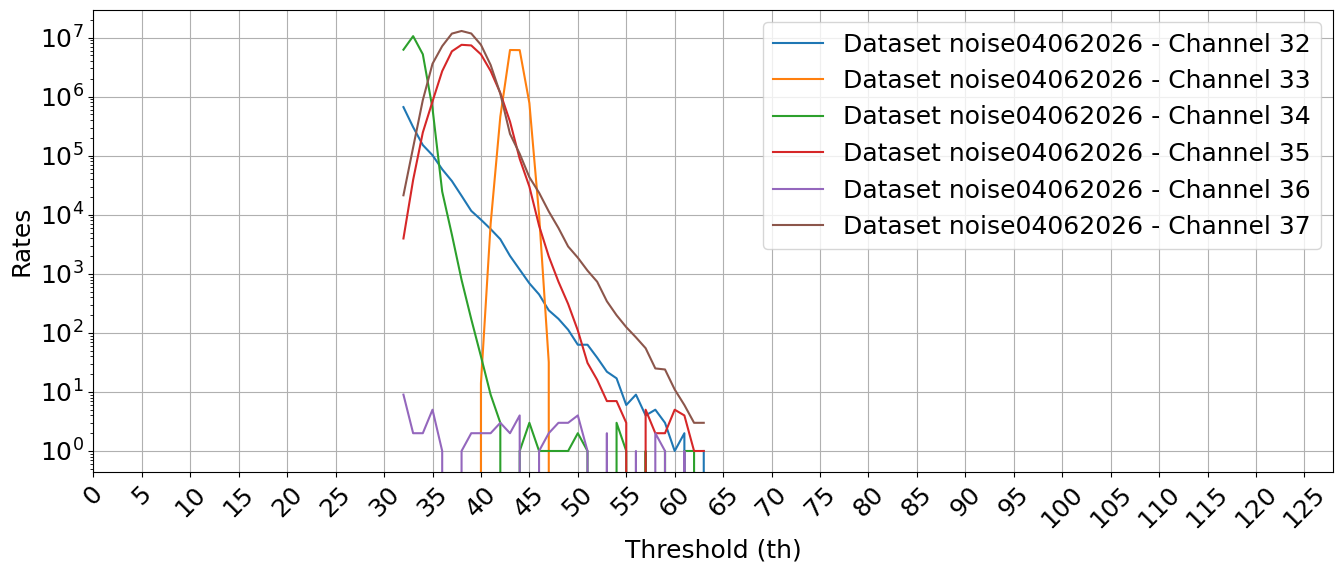

In [33]:
channelsA = [32,33,34,35,36,37]
channelsB = [39,40,41,42,43,44,45,46]
channelsC = [47,48,49,50,51,52,53,54]
channelsD = [55,56,57,58,59,60,61,62]
channelsD = [63,64,65,66,67,68,69,70]
referenz = 101
#with open('/home/mu3e/code_temp/Files/t/2026-05-18_13-23_tscan.json', 'r') as f:
with open('../data/tthreshold_scan.noise04062026.json', 'r') as f:
    data = json.load(f)
    plot_threshold_scan(data, ['noise04062026'], channelsA, -1, 0,128)

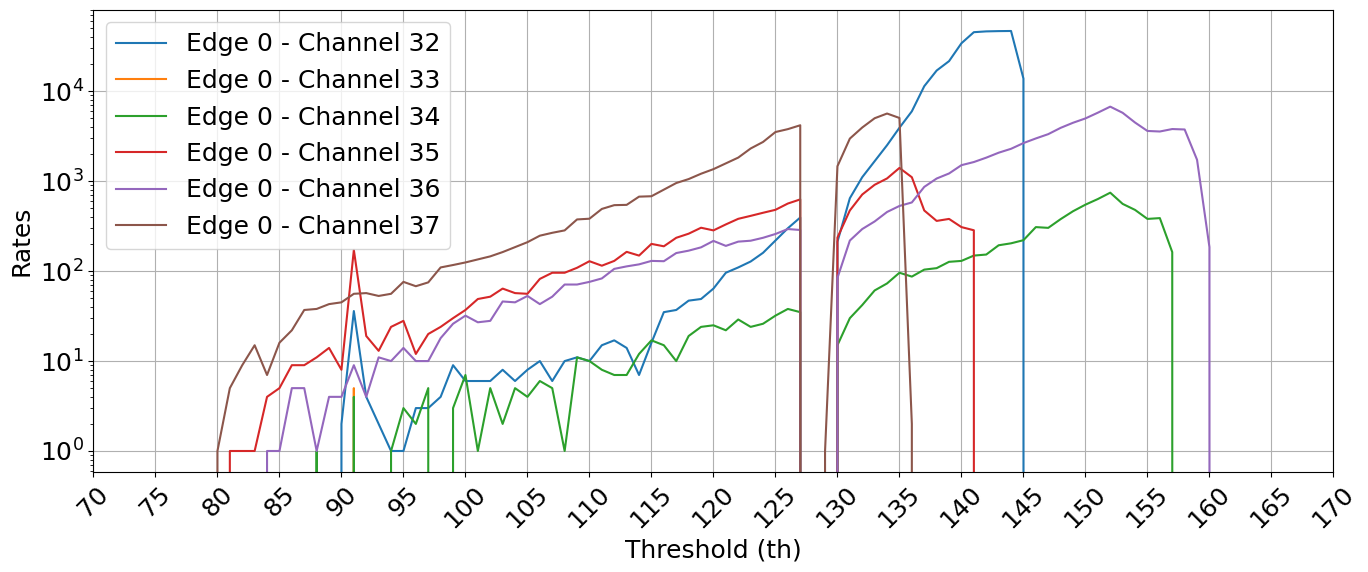

In [ ]:
with open('../data/ethreshold_scan-beam04062026_edge0.json', 'r') as f:
    data = json.load(f)
    plot_threshold_scan(data, ["Edge 0"], channelsA, -1, 70,170)

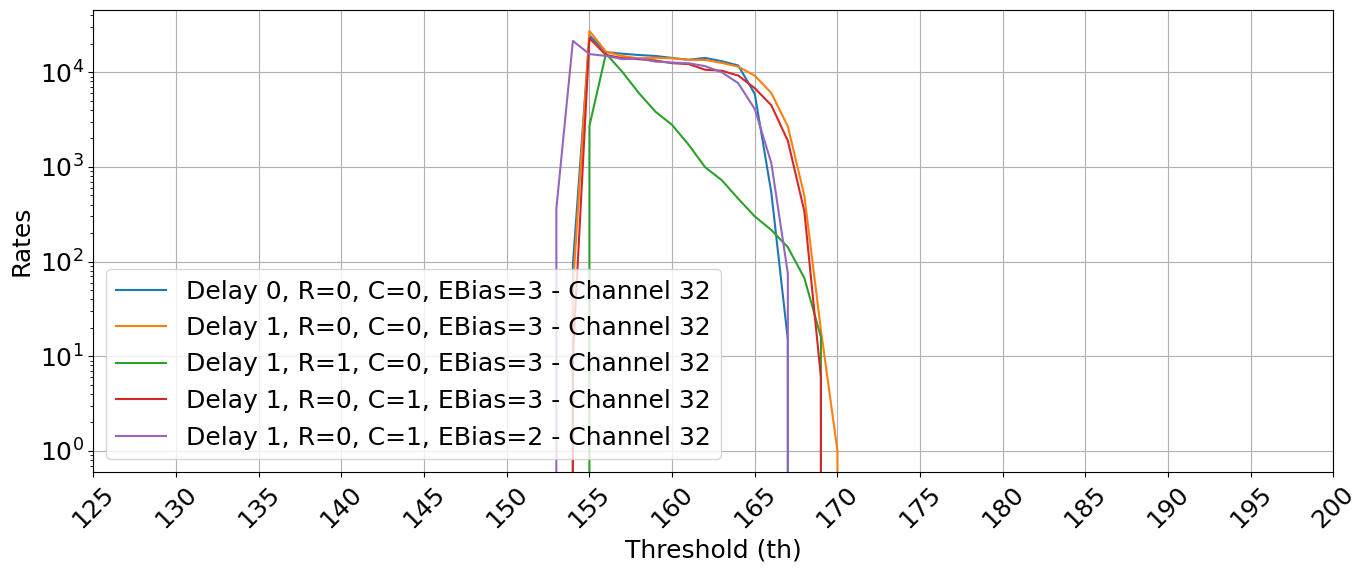

In [42]:
channels = [32]
f = [
    open('../data/ethreshold_scan-beam04062026_edge1-delay0.json', 'r'),
    open('../data/ethreshold_scan-beam04062026_edge1-delay1.json', 'r'),
    open('../data/ethreshold_scan-beam04062026_edge1-delay1-r1.json', 'r'),
    open('../data/ethreshold_scan-beam04062026_edge1-delay1-r0-c1.json', 'r'),
    open('../data/ethreshold_scan-beam04062026_edge1-delay1-r0-c0-ebias2.json', 'r'),
    ]
data = [json.load(file) for file in f]
names = ["Delay 0, R=0, C=0, EBias=3", "Delay 1, R=0, C=0, EBias=3", "Delay 1, R=1, C=0, EBias=3", "Delay 1, R=0, C=1, EBias=3", "Delay 1, R=0, C=1, EBias=2"]
plot_threshold_scan(data, names, channels, -1, 125,200)

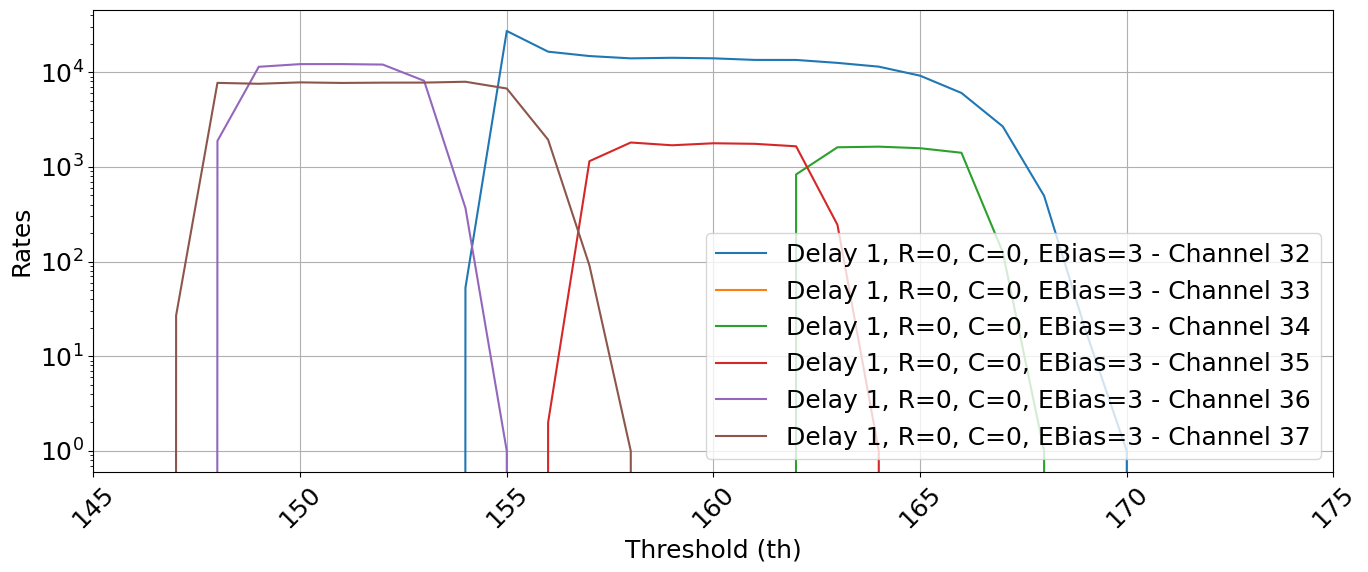

In [47]:
f = [
    open('../data/ethreshold_scan-beam04062026_edge1-delay1.json', 'r'),
    ]
data = [json.load(file) for file in f]
names = ["Delay 1, R=0, C=0, EBias=3"]
plot_threshold_scan(data, names, channelsA, -1, 145,175)

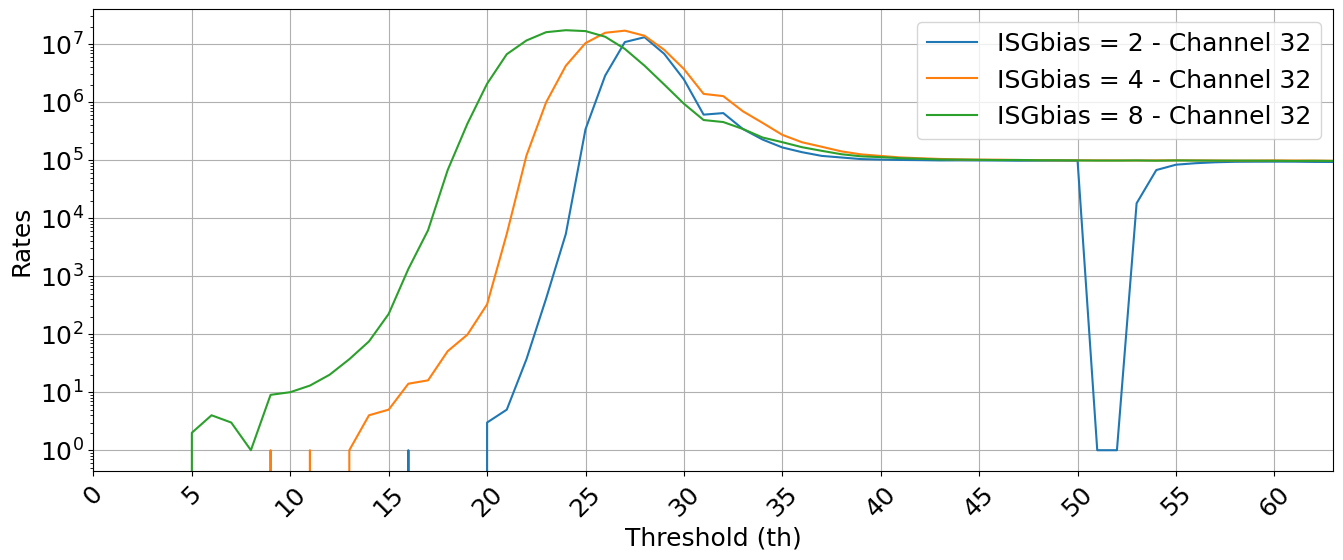

In [52]:
channels = [32]
f = [
    open('../data/tthreshold_scan-isgbias2.json', 'r'),
    open('../data/tthreshold_scan-isgbias4.json', 'r'),
    open('../data/tthreshold_scan-isgbias8.json', 'r'),
    ]
data = [json.load(file) for file in f]
names = ["ISGbias = 2", "ISGbias = 4", "ISGbias = 8"]
plot_threshold_scan(data, names, channels, -1, 0,63)

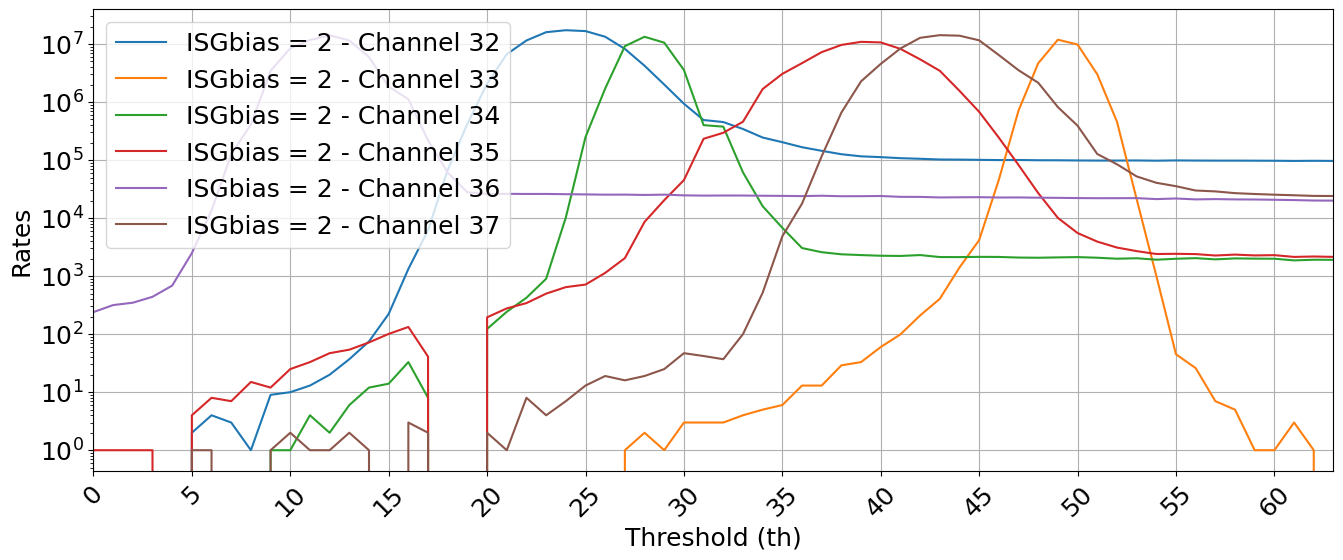

In [53]:

f = [
    open('../data/tthreshold_scan-isgbias8.json', 'r'),
    ]
data = [json.load(file) for file in f]
names = ["ISGbias = 2", "ISGbias = 4", "ISGbias = 8"]
plot_threshold_scan(data, names, channelsA, -1, 0,63)